# Model 2 — Storage-as-a-Service TCO Model
**Part 2 of 4 in *Consumption Pricing Models for Enterprise Infrastructure***

> **A note on inputs and provenance:** All inputs are illustrative, drawn from publicly available industry benchmarks. No proprietary or confidential data is used. The insurance Monte Carlo in particular is a clean-room rebuild from public actuarial methodology — not the production model from any prior role. See the README for full context.

## What this model does

A 5-year total-cost comparison: a CapEx-front-loaded on-premises deployment against a consumption-based STaaS subscription, given assumed demand growth, overprovisioning, data reduction, hardware refresh, and labor + power overhead.

The core insight isn't the headline savings number — it's the *cash flow profile*. CapEx storage forces customers to buy for Year-5 peak demand on Day 1, then sit at low utilization for years. Consumption pricing flattens the curve.

See `01_insurance_monte_carlo.ipynb` for the foundational Monte Carlo methodology that Models 3 and 4 build on.


## Setup — Imports & Shared Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
PURPLE = '#7C3AED'
TEAL   = '#0891B2'
GRAY   = '#6B7280'

def fmt_k(n):
    """Format a number as a compact dollar string."""
    if abs(n) >= 1_000_000:
        return f'${n/1_000_000:.1f}M'
    if abs(n) >= 1_000:
        return f'${n/1_000:.0f}K'
    return f'${n:.0f}'

print('Setup complete.')

Setup complete.


A customer expecting 500TB today growing at 20%/year needs ~1,245TB at Year 5.  
Add a 30% overprovisioning buffer → they must provision **~1,618TB in Year 1**.  
Apply 3:1 data reduction → they buy **~540TB of physical raw hardware** on Day 1.

They pay for that 540TB in Year 1 when they're actually only using 600TB logical (~37% utilization).  
**STaaS bills on actual consumption each year. Zero overprovisioning waste.**

### Cost components

| Layer | On-premises | STaaS |
|---|---|---|
| Hardware | CapEx upfront ($3,500/TB list) + Year-3 refresh | None — vendor owns it |
| Power & cooling | $80/TB physical/yr | None |
| IT labor | $150/TB physical/yr (dedicated storage admin) | None |
| Committed usage | Pay for provisioned capacity | Pay for actual demand |
| Burst | N/A — you provisioned the buffer | +40% premium above committed rate |


### Assumptions

In [5]:
# ── Model 2 Assumptions ────────────────────────────────────────────────

# Workload
BASE_TB      = 500       # Starting logical capacity requirement
GROWTH_RATE  = 0.20      # 20% annual demand growth (IDC benchmark)
OVERPROV     = 0.30      # On-prem overprovisioning buffer for peak demand
DATA_RED     = 3.0       # Data reduction ratio (compression + dedup)
YEARS        = 5

# On-prem cost drivers (per TB physical)
HW_PER_TB    = 3_500     # Enterprise all-flash array list price
POWER_YR     = 80        # Power + cooling per TB physical per year
LABOR_YR     = 150       # Dedicated storage admin allocation
REFRESH_FRAC = 0.35      # Year-3 technology refresh = 35% of original CapEx

# STaaS pricing
KS_RATE_MO   = 35        # $/TB/mo committed rate
BURST_PCT    = 0.15      # Average burst usage as % of committed
BURST_PREM   = 0.40      # Burst billed at 40% premium

# Derived on-prem sizing (must provision for 5-year peak TODAY)
peak_logical  = BASE_TB * (1 + GROWTH_RATE) ** YEARS * (1 + OVERPROV)
peak_physical = peak_logical / DATA_RED
hw_capex      = peak_physical * HW_PER_TB
hw_amort      = hw_capex / YEARS
annual_opex   = peak_physical * (POWER_YR + LABOR_YR)
refresh_cost  = hw_capex * REFRESH_FRAC

print(f'Peak demand (Year 5, with buffer): {peak_logical:.0f} TB logical')
print(f'Physical storage purchased (Day 1): {peak_physical:.0f} TB')
print(f'Hardware CapEx (Year 0): {fmt_k(hw_capex)}')
print(f'Annual amortized HW cost: {fmt_k(hw_amort)}')
print(f'Annual OpEx (power + labor): {fmt_k(annual_opex)}')
print(f'Year-3 refresh cost: {fmt_k(refresh_cost)}')

Peak demand (Year 5, with buffer): 1617 TB logical
Physical storage purchased (Day 1): 539 TB
Hardware CapEx (Year 0): $1.9M
Annual amortized HW cost: $377K
Annual OpEx (power + labor): $124K
Year-3 refresh cost: $660K


### Year-by-Year Calculation

In [6]:
results = []
cum_op = cum_ks = 0.0

print(f'{"Year":<6} {"Demand TB":<12} {"Utilization":<14} {"On-Prem $K":<14} {"STaaS $K":<14} {"Savings $K"}')
print('-' * 70)

for yr in range(1, YEARS + 1):
    demand = BASE_TB * (1 + GROWTH_RATE) ** yr

    # On-prem: fixed amortized cost (hardware already bought) + Year-3 spike
    op_yr = hw_amort + annual_opex + (refresh_cost if yr == 3 else 0)

    # STaaS: pay for actual usage + burst
    burst  = demand * BURST_PCT
    ks_yr  = (demand * KS_RATE_MO + burst * KS_RATE_MO * (1 + BURST_PREM)) * 12

    cum_op += op_yr
    cum_ks += ks_yr
    utilization = demand / peak_logical * 100

    results.append({
        'year': yr, 'demand': demand, 'utilization': utilization,
        'op_yr': op_yr, 'ks_yr': ks_yr,
        'cum_op': cum_op, 'cum_ks': cum_ks,
        'savings_yr': op_yr - ks_yr,
    })
    note = ' <-- refresh spike' if yr == 3 else ''
    print(f'  Y{yr}   {demand:<12.0f} {utilization:<14.1f} {op_yr/1000:<14.0f} {ks_yr/1000:<14.0f} {(op_yr-ks_yr)/1000:.0f}{note}')

total_savings = results[-1]['cum_op'] - results[-1]['cum_ks']
savings_pct   = total_savings / results[-1]['cum_op'] * 100
print(f'\n5-year total savings: {fmt_k(total_savings)} ({savings_pct:.0f}%)')

Year   Demand TB    Utilization    On-Prem $K     STaaS $K       Savings $K
----------------------------------------------------------------------
  Y1   600          37.1           501            305            196
  Y2   720          44.5           501            366            135
  Y3   864          53.4           1162           439            723 <-- refresh spike
  Y4   1037         64.1           501            527            -26
  Y5   1244         76.9           501            632            -131

5-year total savings: $898K (28%)


### Charts

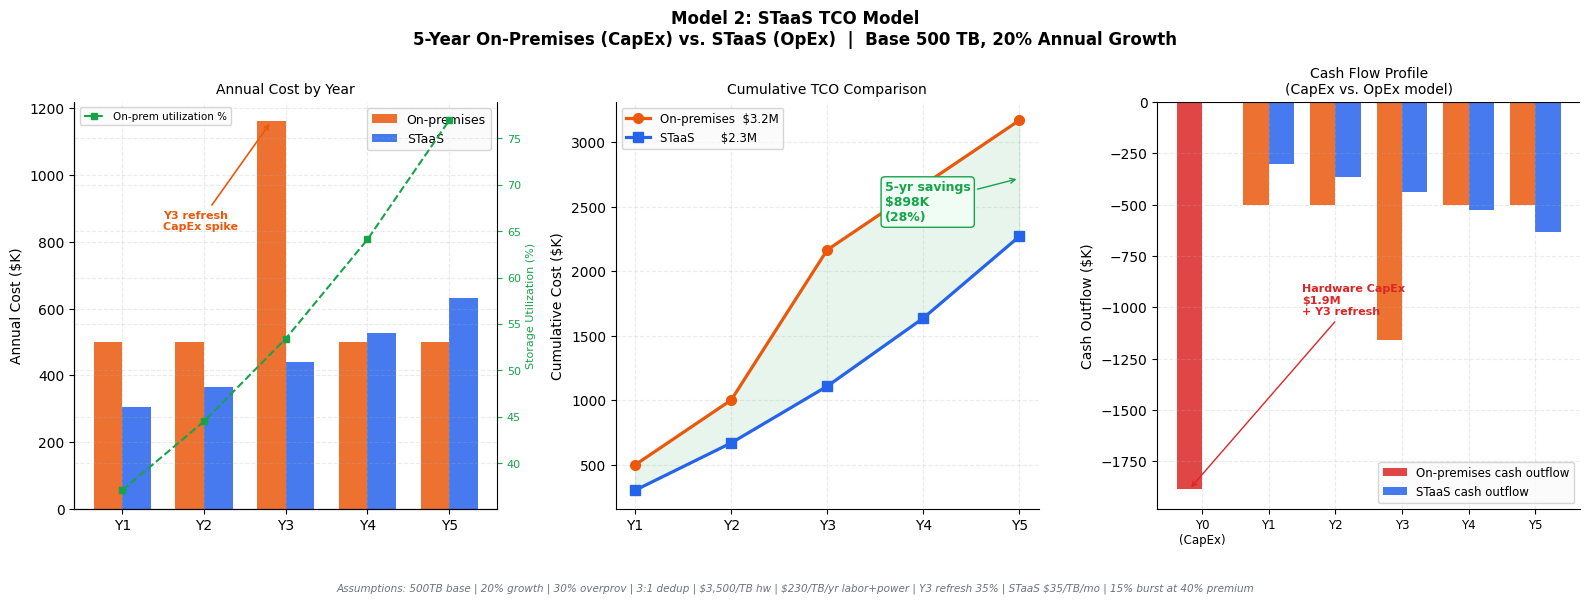

Model 2 complete.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Model 2: STaaS TCO Model\n'
             '5-Year On-Premises (CapEx) vs. STaaS (OpEx)  |  Base 500 TB, 20% Annual Growth',
             fontsize=12, fontweight='bold')

yr_lbl   = [f'Y{r["year"]}' for r in results]
op_k     = [r['op_yr'] / 1_000 for r in results]
ks_k     = [r['ks_yr'] / 1_000 for r in results]
cum_op_k = [r['cum_op'] / 1_000 for r in results]
cum_ks_k = [r['cum_ks'] / 1_000 for r in results]
util     = [r['utilization'] for r in results]
x = np.arange(5)
w = 0.35

# Panel 1: Annual cost + utilization overlay
ax = axes[0]
ax.set_facecolor('white')
ax.bar(x - w/2, op_k, w, label='On-premises', color=ORANGE, alpha=0.85)
ax.bar(x + w/2, ks_k, w, label='STaaS',    color=BLUE,   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(yr_lbl)
ax.set_ylabel('Annual Cost ($K)')
ax.set_title('Annual Cost by Year', fontsize=10)
ax.legend(fontsize=9)
ax.annotate('Y3 refresh\nCapEx spike', xy=(2 - w/2, op_k[2]),
            xytext=(0.5, op_k[2] * 0.72), fontsize=8, color=ORANGE, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))
ax2b = ax.twinx()
ax2b.plot(x, util, 's--', color=GREEN, lw=1.5, ms=5, label='On-prem utilization %')
ax2b.set_ylabel('Storage Utilization (%)', fontsize=8, color=GREEN)
ax2b.tick_params(axis='y', colors=GREEN, labelsize=8)
ax2b.spines['right'].set_visible(True)
ax2b.spines['top'].set_visible(False)
ax2b.legend(fontsize=7.5, loc='upper left')

# Panel 2: Cumulative TCO
ax = axes[1]
ax.set_facecolor('white')
ax.plot(yr_lbl, cum_op_k, 'o-', color=ORANGE, lw=2.3, ms=7,
        label=f'On-premises  {fmt_k(results[-1]["cum_op"])}')
ax.plot(yr_lbl, cum_ks_k, 's-', color=BLUE,   lw=2.3, ms=7,
        label=f'STaaS       {fmt_k(results[-1]["cum_ks"])}')
ax.fill_between(yr_lbl, cum_ks_k, cum_op_k, alpha=0.10, color=GREEN)
ax.set_ylabel('Cumulative Cost ($K)')
ax.set_title('Cumulative TCO Comparison', fontsize=10)
ax.legend(fontsize=8.5)
mid = (cum_op_k[-1] + cum_ks_k[-1]) / 2
ax.annotate(f'5-yr savings\n{fmt_k(total_savings)}\n({savings_pct:.0f}%)',
            xy=(4, mid), xytext=(2.6, mid * 0.88),
            fontsize=9, color=GREEN, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FDF4', edgecolor=GREEN),
            arrowprops=dict(arrowstyle='->', color=GREEN))

# Panel 3: Cash flow profile (CapEx vs. OpEx — the CFO conversation)
ax = axes[2]
ax.set_facecolor('white')
bar_pos = np.arange(-1, 5)
op_cash = [-hw_capex / 1_000] + [-(hw_amort + annual_opex + (refresh_cost if yr==3 else 0)) / 1_000
                                   for yr in range(1, 6)]
ks_cash_bars = [-v for v in ks_k]
bw = 0.38
colors_op = ['#DC2626'] + [ORANGE] * 5
ax.bar(bar_pos - bw/2, op_cash, bw, color=colors_op, alpha=0.85, label='On-premises cash outflow')
ax.bar(bar_pos[1:] + bw/2, ks_cash_bars, bw, color=BLUE, alpha=0.85, label='STaaS cash outflow')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(bar_pos)
ax.set_xticklabels(['Y0\n(CapEx)'] + yr_lbl, fontsize=8.5)
ax.set_ylabel('Cash Outflow ($K)')
ax.set_title('Cash Flow Profile\n(CapEx vs. OpEx model)', fontsize=10)
ax.legend(fontsize=8.5)
ax.annotate(f'Hardware CapEx\n{fmt_k(hw_capex)}\n+ Y3 refresh',
            xy=(-1 - bw/2, -hw_capex / 1_000),
            xytext=(0.5, -hw_capex / 1_000 * 0.55),
            fontsize=8, color='#DC2626', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#DC2626'))

fig.text(0.5, 0.01,
         'Assumptions: 500TB base | 20% growth | 30% overprov | 3:1 dedup | '
         '$3,500/TB hw | $230/TB/yr labor+power | Y3 refresh 35% | '
         'STaaS $35/TB/mo | 15% burst at 40% premium',
         ha='center', fontsize=7.5, color=GRAY, style='italic')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('model2_staas_tco.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Model 2 complete.')